In [1]:
import os
import csv
import pandas as pd
import numpy as np
from skimage import io
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import math

import torch
from torch import nn, Tensor
from torch.nn import functional as F
from torch.utils import data as tdata

from torchvision import utils as vutils,transforms as T 
from torchvision.datasets import ImageFolder
from transformers import ViTImageProcessor, ViTForImageClassification
import pytorch_lightning as pl

In [2]:
random_seed = 42
pl.seed_everything(random_seed) 

np.random.randint(0,100)



Seed set to 42


51

In [3]:
hugging_model_name = 'google/vit-base-patch16-224-in21k'
image_processor = ViTImageProcessor.from_pretrained(hugging_model_name)
image_processor

ViTImageProcessor {
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}

In [77]:
train_path='/home/fred/asl/asl_alphabet_train/'
kaggle_write_path = os.path.expanduser("~/asl")
mean, std = image_processor.image_mean, image_processor.image_std
img_size= image_processor.size

In [67]:
ls


lightning_logs/


In [5]:
print(image_processor.size)

SizeDict(height=224, width=224, longest_edge=None, shortest_edge=None, max_height=None, max_width=None)


In [6]:
def get_dir(root_path):
    """ Returns '(list_classes, classes_to_idx,nump array mapping path to class_idx)"""
    if not os.path.exists(root_path):
        raise FileNotFoundError("Folder does not exist")

    classes = sorted(os.listdir(root_path))
    classes_to_idx = { c: i for i,c in enumerate(classes)}

    all_samples= []
# _____________________________________________________________________________
    for idx, cl in enumerate(classes):
        path= os.path.join(root_path, cl)

        all_files = os.listdir(path)

        #add (path, class_idx) to all_samples 

        all_samples.extend([[p,idx] for p in all_files])

    all_samples = np.array(all_samples)

    return classes, classes_to_idx, all_samples

all_classes, classes_to_idx, all_samples = get_dir(train_path)
        

In [7]:
print(f"Number of samples: {len(all_samples)}")
train_ratio= 0.8
train_samples,test_samples= train_test_split(all_samples,shuffle=True, train_size=train_ratio)
print(f"Length of split: {len(train_samples)},{len(test_samples)}")
train_samples[0],test_samples[0]

Number of samples: 87000
Length of split: 69600,17400


(array(['U2346.jpg', '23'], dtype='<U21'),
 array(['R964.jpg', '19'], dtype='<U21'))

In [8]:
"""import numpy as np

# 1. Definimos una lista de categorías (como si fueran carpetas)
classes = ['gato', 'perro', 'pájaro']

# 2. Preparamos una lista vacía para guardar los resultados
all_samples = []

print("--- INICIANDO EL BUCLE ---\n")

# 3. Recorremos la lista de clases enumerándola
for idx, cl in enumerate(classes):
    print(f"-> Procesando clase número {idx}: '{cl}'")
    
    # Simulamos los archivos que habría dentro de cada carpeta
    if cl == 'gato':
        all_files = ['gato1.jpg', 'gato2.jpg']
    elif cl == 'perro':
        all_files = ['perro1.jpg']
    else:
        all_files = ['pajaro1.jpg', 'pajaro2.jpg', 'pajaro3.jpg']
    
    print(f"   Archivos encontrados: {all_files}")
    
    # Creamos las parejas [archivo, número_de_clase] y las agregamos
    muestras_clase = [[p, idx] for p in all_files]
    print(f"   Emparejados con su índice ({idx}): {muestras_clase}\n")
    
    all_samples.extend(muestras_clase)

# 4. Convertimos la lista final a una matriz de NumPy
all_samples = np.array(all_samples)

print("--- RESULTADO FINAL ---")
print("Matriz 'all_samples':")
print(all_samples)"""

'import numpy as np\n\n# 1. Definimos una lista de categorías (como si fueran carpetas)\nclasses = [\'gato\', \'perro\', \'pájaro\']\n\n# 2. Preparamos una lista vacía para guardar los resultados\nall_samples = []\n\nprint("--- INICIANDO EL BUCLE ---\n")\n\n# 3. Recorremos la lista de clases enumerándola\nfor idx, cl in enumerate(classes):\n    print(f"-> Procesando clase número {idx}: \'{cl}\'")\n    \n    # Simulamos los archivos que habría dentro de cada carpeta\n    if cl == \'gato\':\n        all_files = [\'gato1.jpg\', \'gato2.jpg\']\n    elif cl == \'perro\':\n        all_files = [\'perro1.jpg\']\n    else:\n        all_files = [\'pajaro1.jpg\', \'pajaro2.jpg\', \'pajaro3.jpg\']\n    \n    print(f"   Archivos encontrados: {all_files}")\n    \n    # Creamos las parejas [archivo, número_de_clase] y las agregamos\n    muestras_clase = [[p, idx] for p in all_files]\n    print(f"   Emparejados con su índice ({idx}): {muestras_clase}\n")\n    \n    all_samples.extend(muestras_clase)\n

In [9]:
idx_to_class= {i: d for (i,d) in enumerate (all_classes)}
num_classes=len(all_classes)
str([num_classes,idx_to_class])

"[29, {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'DEL', 5: 'E', 6: 'F', 7: 'G', 8: 'H', 9: 'I', 10: 'J', 11: 'K', 12: 'L', 13: 'M', 14: 'N', 15: 'NOTHING', 16: 'O', 17: 'P', 18: 'Q', 19: 'R', 20: 'S', 21: 'SPACE', 22: 'T', 23: 'U', 24: 'V', 25: 'W', 26: 'X', 27: 'Y', 28: 'Z'}]"

In [10]:
class CustomDataset(tdata.Dataset):
    def __init__(self, root_path,samples,classes,transform=None,transform_args=[]):
        """sumary

        Args:
            root_path(_type_): path from where data will be read.Like 'imageFolder', pass in folder path where folders
            inside it will be treated as classes.
            samples(_type_): a numpy array that will have rows that map 'image_path, class_idx)'
            classes (_type_): a list of all classes names
            transform (_type_, optional): IF provided, can be torch transforms or hugginFace image processors. Defaults to None
            transform_args (list, optional): is a list of '(argument, values)' Defaults to [] """

        self.root_path = root_path
        self.samples = samples
        self.transform = transform
        self.classes= classes

        self.transform_args={}
        for key, val in transform_args:
            self.transform_args[key] = val

        print(self.transform_args)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
            file_name, target=self.samples[idx]
            target = int(target)
            file_path = os.path.join(self.root_path, self.classes[target],file_name)

            img=io.imread(file_path)


            if self.transform is not None:
                img = self.transform(img, **self.transform_args)

            return img["pixel_values"][0], target
            
        

In [12]:
transform_args=[("return_tensors","pt")]

train_dataset=CustomDataset(train_path,train_samples,all_classes,transform=image_processor,transform_args=transform_args)


valid_dataset=CustomDataset(train_path,test_samples,all_classes,transform=image_processor,transform_args=transform_args)
len(train_dataset),len(valid_dataset)

{'return_tensors': 'pt'}
{'return_tensors': 'pt'}


(69600, 17400)

In [18]:
train_dataset[0][0].shape

torch.Size([3, 224, 224])

In [19]:
def denorm(tensor,mean=mean,std=std):
    """ denormalizar"""
    mean,std= torch.tensor([mean]),torch.tensor([std])
    output=std*tensor+mean
    return torch.clamp(output,0,1)

In [23]:
def plot_image(tensor, label=None, denormalise=True):
    """tensor es de forma(h,w,c)"""
    plt.tick_params(left=False,bottom=False,labelleft=False,labelbottom=False)

    if label is not None:
        plt.title(str(label))

    if denormalise:
        tensor=denorm(tensor)
        tensor.permute(1,2,0)# (Channel ,height, width)) -> (height,width,channel)

    plt.imshow(tensor)

In [26]:
def plot_grid(tensor,n_row):
    """input is of shape (batch_size,C,h,w)"""
    grid_tensor= vutils.make_grid(tensor,n_row).permute(1,2,0)
    plot_image(grid_tensor,"grid of random ASL images")
    

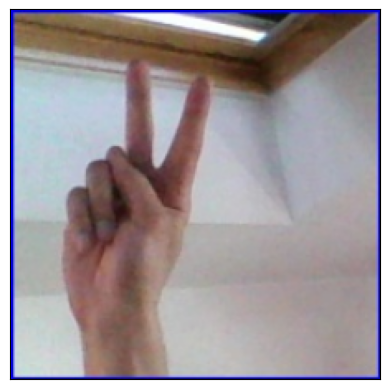

In [39]:
img=train_dataset[1][0].permute(1,2,0)
plot_image(img)

torch.Size([64, 3, 224, 224])


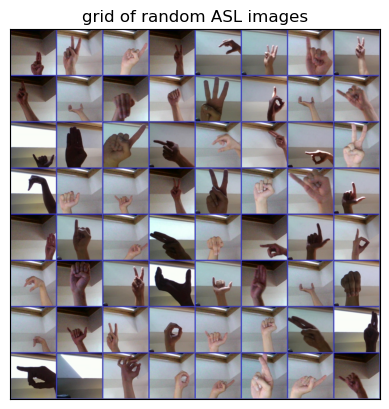

In [53]:
from torch.utils.data import BatchSampler, SequentialSampler
batch_size=64

def get_loader(dataset,batch_size,num_workers=0):
    """ simple utility funcion to instantiate a dataLoader"""
    persistent_workers = True if num_workers > 0 else False

    sampler=BatchSampler(SequentialSampler(dataset),batch_size,drop_last=False)

    return tdata.DataLoader(dataset,batch_sampler=sampler,
                            num_workers=num_workers,
                            # this flag
                            persistent_workers=persistent_workers)

train_loader=get_loader(train_dataset,batch_size,2)
test_loader=get_loader(valid_dataset,batch_size,2)

# check if the dataloader works fine by plotting a grid of images
for images, labels in train_loader:
    print(images.shape)
    plot_grid(images, 8)
    break
    

In [54]:
class ViTTrainingModule(pl.LightningModule):
    def __init__(self, num_labels: int, hugging_model_name: str, lr: int = 3e-4):
        super(ViTTrainingModule,self).__init__()
        self.vit= ViTForImageClassification.from_pretrained(hugging_model_name,num_labels=num_labels,id2label=idx_to_class,
                                                            label2id=classes_to_idx, ignore_mismatched_sizes=True)
        self.lr=lr

    def forward(self,pixel_values):
        outputs = self.vit(pixel_values)
        return output["logits"]

    def common_step(self,batch):

        images, labels = batch
        outputs = self.vit(images)["logits"]

        l = F.cross_entropy(outputs, labels)
        preds= torch.argmax(outputs, dim=-1)
        num_correct = (preds == labels).sum().item()
        accuracy = num_correct / len(batch)

        return l, accuracy 

    def training_step(self, batch,batch_idx):

        l, accuracy = self.common_step(batch)

        self.log("training_loss",l)
        self.log("training_acurracy")

        return l

    def validation_step(self,batch,batch_idx):
        l, accuracy = self.common_step(batch)

        self.log("val_loss",l)
        self.log("val_accuracy",accuracy)

        return l

    def configure_optimizers(self):
        optimizer = toch.optim.AdamW(self.parameters(), self.lr)
        return optimizer

    def train_dataloader(self):
        return train_loader

    def val_dataloader(self):
        return val_loader

In [81]:
%load_ext tensorboard
%tensorboard --logdir /home/fred/asl/code/working/lightning_logs/

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6008 (pid 18339), started 1:11:49 ago. (Use '!kill 18339' to kill it.)

In [87]:
# defining the number of GPUs because PL makes it very easy for us to
# parallelize training across multiple GPUs
num_devices = torch.cuda.device_count()
num_devices

1

In [83]:
checkpoint_path = os.path.join(kaggle_write_path, "checkpoints")

print(os.listdir(checkpoint_path))
load_checkpoint_file = os.path.join(checkpoint_path, 'epoch=01-val_loss=0.02-v1.ckpt')

['.ipynb_checkpoints']


In [82]:
print(os.listdir(checkpoint_path))

[]


In [84]:
print("Python está buscando exactamente aquí:", os.path.abspath(checkpoint_path))


Python está buscando exactamente aquí: /home/fred/asl/checkpoints


In [92]:
custom_checkpoint_path = os.path.join(kaggle_write_path, 'custom.pth')

checkpoint_callback = pl.callbacks.ModelCheckpoint(
  dirpath=checkpoint_path,
  save_top_k=2,
  every_n_train_steps=50,
  mode="min",
  monitor="training_loss",
  filename="{epoch:02d}-{val_loss:.2f}"
)

early_stop_callback = pl.callbacks.EarlyStopping(
  monitor='val_loss',
  patience=3,
  strict=False,
  verbose=False,
  mode='min'
)

model = ViTTrainingModule(num_classes, hugging_model_name)

trainer_args = {
    "accelerator": "gpu",
    "devices": num_devices,
    "strategy": "ddp_notebook",
    "log_every_n_steps": 5,
    "callbacks": [early_stop_callback, checkpoint_callback],
    "max_epochs": 3,
}
trainer = pl.Trainer(**trainer_args)

trainer.fit(model, ckpt_path=load_checkpoint_file)

Loading weights:   0%|          | 0/6 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
encoder.layer.{0...11}.layernorm_after.weight           | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.value.bias   | UNEXPECTED | 
encoder.layer.{0...11}.attention.output.dense.bias      | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.bias             | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.query.bias   | UNEXPECTED | 
encoder.layer.{0...11}.intermediate.dense.weight        | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_before.weight          | UNEXPECTED | 
encoder.layer.{0...11}.attention.output.dense.weight    | UNEXPECTED | 
encoder.layer.{0...11}.output.dense.weight              | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.key.weight   | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.

ProcessRaisedException: 

-- Process 0 terminated with the following error:
Traceback (most recent call last):
  File "/home/fred/miniconda3/envs/Deus/lib/python3.10/site-packages/torch/multiprocessing/spawn.py", line 90, in _wrap
    fn(i, *args)
  File "/home/fred/miniconda3/envs/Deus/lib/python3.10/site-packages/pytorch_lightning/strategies/launchers/multiprocessing.py", line 173, in _wrapping_function
    results = function(*args, **kwargs)
  File "/home/fred/miniconda3/envs/Deus/lib/python3.10/site-packages/pytorch_lightning/trainer/trainer.py", line 630, in _fit_impl
    self._run(model, ckpt_path=ckpt_path, weights_only=weights_only)
  File "/home/fred/miniconda3/envs/Deus/lib/python3.10/site-packages/pytorch_lightning/trainer/trainer.py", line 1046, in _run
    self._checkpoint_connector._restore_modules_and_callbacks(ckpt_path, weights_only)
  File "/home/fred/miniconda3/envs/Deus/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/checkpoint_connector.py", line 